# k-Nearest Neighbors

***

## Importando bibliotecas

In [ ]:
# Bibliotecas de manipulação e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

# Classes do modelo de aprendizado
from sklearn.neighbors import KNeighborsClassifier

# Funções de avaliação dos modelos
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Análise do conjunto de dados

In [7]:
#carregando o csv
dataset = pd.read_csv("https://raw.githubusercontent.com/johnattandouglas/monitoria-ml/main/Datasets/Iris.csv")

**Dataset Iris**

<img src="https://miro.medium.com/v2/resize:fit:1000/1*nfK3vGZkTa4GrO7yWpcS-Q.png" alt="Iris" width="600"/>

In [8]:
dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [9]:
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


loc (rótulos) x iloc (indíces)

In [10]:
# dataset.loc[0:5, 'SepalWidthCm']
# dataset.iloc[0:5, 1]

In [11]:
dataset.shape

(150, 5)

In [12]:
# Coluna com as features
target_col = "Species"
print("Quantas classes existem nesse dataset?\n%d" %(len(dataset[target_col].unique())))
print("\nQuantas instâncias existem no dataset?\n%d" % dataset.shape[0])
print("\nQuantas features existem no dataset?\n%d" % (dataset.shape[1]-1))
print("\nQue features são essas?\n%s" % (str([k for k in dataset.keys() if k != target_col])))
print("\nQual o numero de instâncias por classe?")
print(dataset[target_col].value_counts())

Quantas classes existem nesse dataset?
3

Quantas instâncias existem no dataset?
150

Quantas features existem no dataset?
4

Que features são essas?
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Qual o numero de instâncias por classe?
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


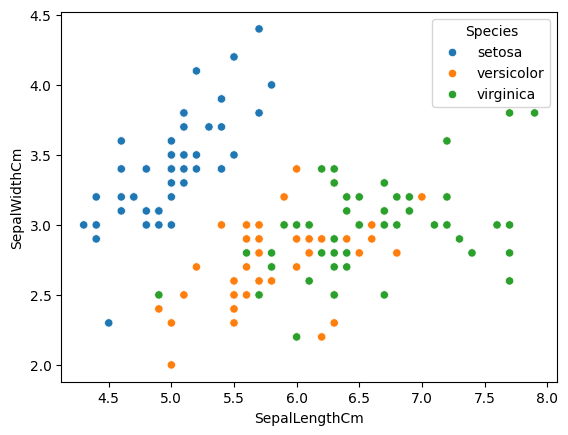

In [13]:
# Visualização dos registros considerando as features SepalLengthCm e SepalWidthCm
sns.scatterplot(data=dataset, x='SepalLengthCm', y='SepalWidthCm', hue='Species')

# Adiciona a legenda
# plt.legend(title='Espaço de características da Sepal (Length x Width)')

# Adiciona rótulos aos eixos
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')

# Exibe o gráfico
plt.show()

Para aplicar o algoritmo KNN, é necessário transformar os dados categóricos em valores numéricos!

In [14]:
pd.factorize(dataset['Species'])

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 Index(['setosa', 'versicolor', 'virginica'], dtype='object'))

`pd.factorize` é uma função do pandas que converte valores categóricos em valores numéricos inteiros. Ela cria uma codificação numérica para cada valor único encontrado na coluna fornecida.

- Setosa - 0
- Versicolor - 1
- Virginica - 2

`pd.factorize(dataset['Species'])` retorna uma tupla:

- Um array com os valores numéricos correspondentes às categorias.
- Um array com as categorias na ordem em que foram encontradas.

In [15]:
# Mapeando os valores da classe para inteiro (para fins de visualização da região de decisão)
dataset['Species'] = pd.factorize(dataset['Species'])[0]

### Separando o conjunto de dados 

In [16]:
#Vamos usar somente duas features SepalLengthCm e SepalWidthCm
X = dataset.loc[:,["SepalLengthCm", "SepalWidthCm"]] 
y = dataset.loc[:,["Species"]]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Treinamento do modelo

In [17]:
# vamos criar um classificador kNN com k=5
model = KNeighborsClassifier()
model.fit(X_train, y_train)

# e ver a sua performance no dataset de teste
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.77      0.59      0.67        17
           2       0.63      0.80      0.71        15

    accuracy                           0.78        45
   macro avg       0.80      0.80      0.79        45
weighted avg       0.79      0.78      0.78        45



**Métricas de avaliação**

*   **Precision** - $\frac{tp}{(tp + fp)}$
*   **Recall** - $\frac{tp}{(tp + fn)}$ 
*   **F1-score** - $2 * \frac{(precision * recall)}{(precision + recall)}$
*   **Accuracy** - $\frac{C}{T}$
*   **Macro avg** - Calcule as métricas para cada rótulo e encontre sua média não ponderada.
*   **Weighted avg** - Calcule as métricas para cada rótulo e encontre sua média ponderada pelo suporte (o número de instâncias verdadeiras para cada rótulo).

**tp** - verdadeiros positivos

**fp** - falsos positivos

**fn** - falsos negativos

**C** - Número de predições corretas

**T** - Número total de predições

### Região de decisão

In [18]:
def show_decision_region(X, y, model):
    feature_0 = X.columns[0]
    feature_1 = X.columns[1]

    plot_decision_regions(np.array([X[feature_0].values,
                                    X[feature_1].values]).T,
                                    y.values.flatten(), model)
    plt.xlabel(feature_0)
    plt.ylabel(feature_1)

    plt.title(model.__class__.__name__ + " k = " + str(model.n_neighbors))
    plt.show()

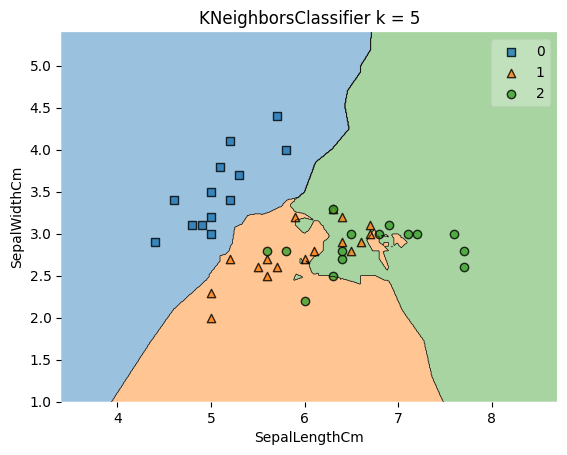

In [19]:
# região de decisão com o tamanho da vizinhança para o kNN
show_decision_region(X_test, y_test, model)

## Análise dos parâmetros

### Quanto o tamanho da vizinhança influencia?

Lembre que n_neighbors >= 1 e n_neighbors <= número de exemplos

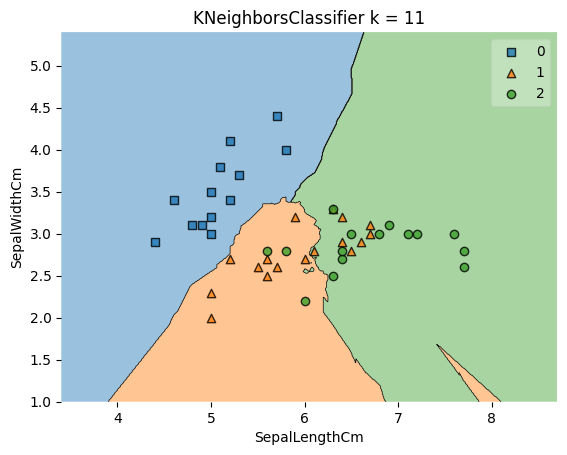

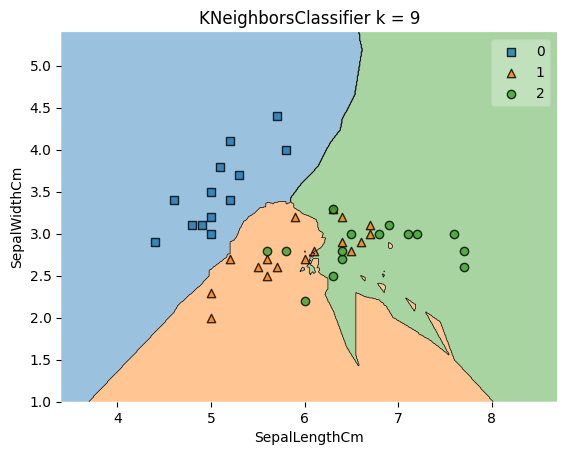

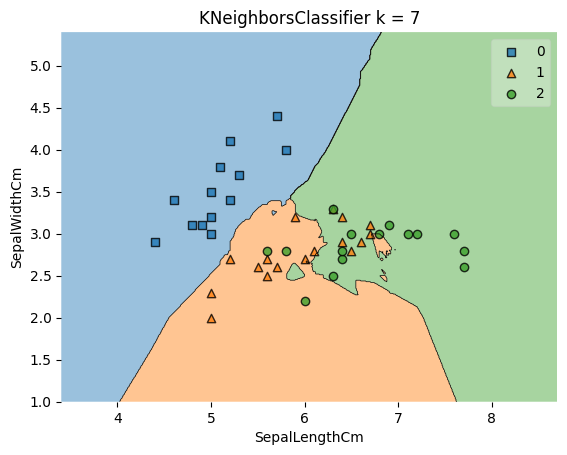

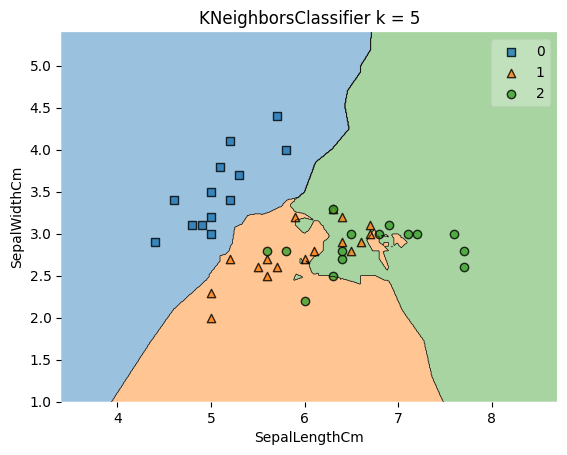

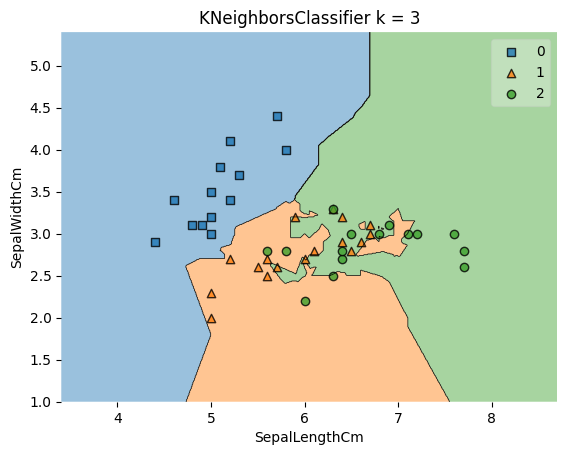

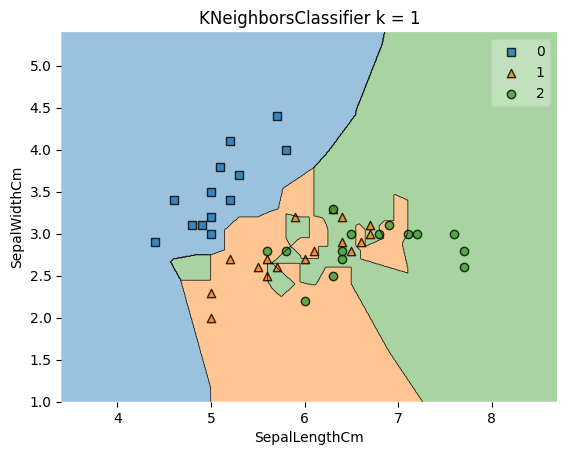

In [20]:
for k in [11, 9, 7, 5, 3, 1]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # performance no dataset de teste
    show_decision_region(X_test, y_test, model)

### Medida de distância

Também podemos mudar a métrica utilizada para calcular a distância entre as amostras.

O hiperparâmetro _metric_ pode assumir dois tipos diferentes, uma _string_ ou uma função. Caso o valor seja uma _string_, as possíveis funções de distâncias estão presentes [aqui](https://scikit-learn.org/0.24/modules/generated/sklearn.neighbors.DistanceMetric.html). Entretanto, você também pode criar uma função que calcula a distância entre métricas.

Vamos definir duas distâncias diferentes, a distância Euclidiana e a distância Manhattan:

- Manhattan: $D_M(x, y) = \sum_{i=1}^{d}|x_i-y_i|$

- Euclidiana: $D(x, y) = \sqrt{\sum_{i=1}^{d}(x_i-y_i)^2}$

<img src="https://uploads-cdn.omnicalculator.com/images/manhattan_distance.png?width=425&enlarge=0&format=webp" alt="Manhattan distance illustration" style="max-width: 425px;">

In [21]:
# vamos implementar uma distância manhattan com pesos diferentes para cada uma das features
def manhattan_custom_distance(x, y, weights=np.array([2, 1])):
    return (abs(x - y)*weights).sum()

--------------------
euclidean
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.77      0.59      0.67        17
           2       0.63      0.80      0.71        15

    accuracy                           0.78        45
   macro avg       0.80      0.80      0.79        45
weighted avg       0.79      0.78      0.78        45



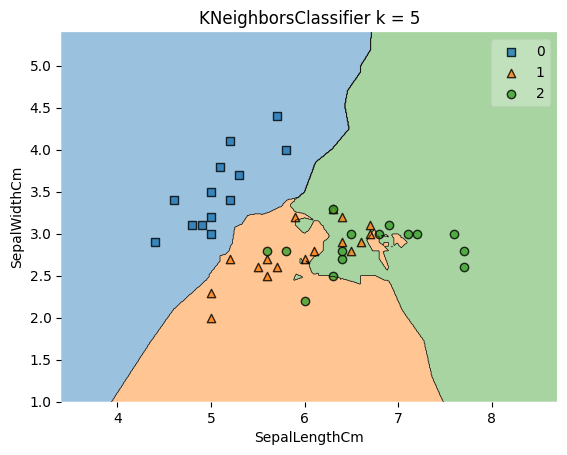

--------------------
manhattan
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.77      0.59      0.67        17
           2       0.63      0.80      0.71        15

    accuracy                           0.78        45
   macro avg       0.80      0.80      0.79        45
weighted avg       0.79      0.78      0.78        45



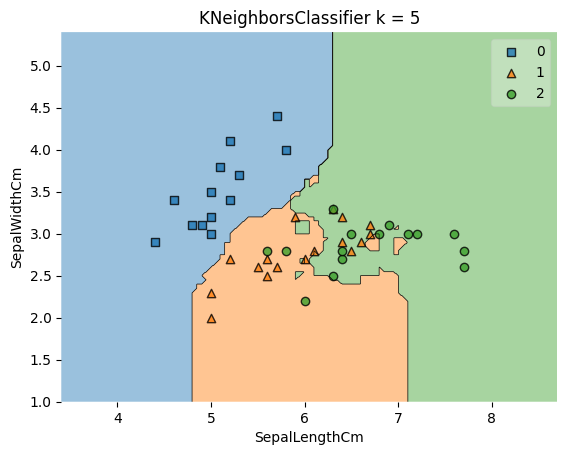

--------------------
<function manhattan_custom_distance at 0x0000018B5D336D40>
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       0.73      0.47      0.57        17
           2       0.63      0.80      0.71        15

    accuracy                           0.73        45
   macro avg       0.74      0.76      0.74        45
weighted avg       0.74      0.73      0.72        45



In [ ]:
for m in ["euclidean", "manhattan", manhattan_custom_distance]:
    print("-"*20)
    print(str(m))

    model = KNeighborsClassifier(n_neighbors=5, metric=m)
    model.fit(X_train, y_train)

    # performance no dataset de test
    print(classification_report(y_test, model.predict(X_test)))

    show_decision_region(X_test, y_test, model)

[Veja esse KNN Interativo!](http://vision.stanford.edu/teaching/cs231n-demos/knn/)

Métrica L1 (Distância de Manhattan)

Métrica L2 (Distância Euclidiana)

## KNN Adaptativo

No **KNN clássico**, o número de vizinhos `k` é **fixo** para todos os pontos. Isso pode ser problemático quando a **densidade dos dados varia** na região:

| Situação | KNN fixo (`k=5`) | Problema |
|----------|------------------|----------|
| Região **densa** | 5 vizinhos num raio pequeno | Pode ser ruidoso (vizinhança muito local) |
| Região **esparsa** | 5 vizinhos num raio grande | Pode misturar classes distantes |

Duas estratégias adaptativas comuns:

1. **KNN por raio** (`RadiusNeighborsClassifier`): o **raio é fixo** e o **número de vizinhos muda** — muitos vizinhos onde há densidade alta, poucos onde há densidade baixa.

2. **KNN com k variável**: o **k muda** conforme a distância ao vizinho mais distante dentro de uma vizinhança candidata — regiões densas usam k menor, regiões esparsas usam k maior.

Abaixo geramos um dataset sintético com um cluster **denso** e outro **esparso** para visualizar a diferença.

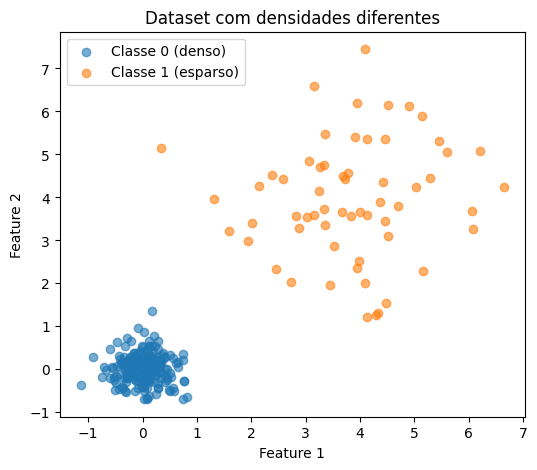

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, NearestNeighbors
from collections import Counter

# Cluster denso (classe 0) + cluster esparso (classe 1)
X_denso, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.35, random_state=42)
X_esparso, _ = make_blobs(n_samples=60, centers=[[4, 4]], cluster_std=1.4, random_state=42)

X_adap = np.vstack([X_denso, X_esparso])
y_adap = np.array([0] * 200 + [1] * 60)

plt.figure(figsize=(6, 5))
plt.scatter(X_denso[:, 0], X_denso[:, 1], alpha=0.6, label="Classe 0 (denso)")
plt.scatter(X_esparso[:, 0], X_esparso[:, 1], alpha=0.6, label="Classe 1 (esparso)")
plt.legend()
plt.title("Dataset com densidades diferentes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 1) KNN por raio — raio fixo, vizinhos variáveis

Com `RadiusNeighborsClassifier`, todos os pontos dentro do raio `r` votam na classificação. Veja quantos vizinhos cada ponto de teste encontra:

In [ ]:
raio = 0.8

modelo_raio = RadiusNeighborsClassifier(radius=raio, outlier_label=-1)
modelo_raio.fit(X_adap, y_adap)

# Pontos de exemplo: um no cluster denso, outro no esparso
pontos_exemplo = np.array([[0.0, 0.0], [4.0, 4.0]])

for i, ponto in enumerate(pontos_exemplo):
    vizinhos_idx = modelo_raio.radius_neighbors([ponto], return_distance=False)[0]
    n_viz = len(vizinhos_idx)
    regiao = "denso" if i == 0 else "esparso"
    print(f"Ponto em região {regiao} {ponto} → {n_viz} vizinhos dentro do raio r={raio}")

print("\nRelatório de classificação (leave-one-out simplificado com split):")
X_tr, X_te, y_tr, y_te = train_test_split(X_adap, y_adap, test_size=0.3, random_state=42, stratify=y_adap)
modelo_raio.fit(X_tr, y_tr)
print(classification_report(y_te, modelo_raio.predict(X_te)))

Ponto em região denso [0. 0.] → 190 vizinhos dentro do raio r=0.8
Ponto em região esparso [4. 4.] → 13 vizinhos dentro do raio r=0.8

Relatório de classificação (leave-one-out simplificado com split):


NameError: name 'train_test_split' is not defined

### 2) KNN com k variável — densidade define o k

Implementação didática: medimos a distância ao vizinho mais distante entre os `k_max` candidatos. Se essa distância é **pequena** (região densa), usamos **k menor**; se é **grande** (região esparso), usamos **k maior**.

In [ ]:
class KNNAdaptativo:
    """KNN em que k local varia entre k_min e k_max conforme a densidade."""

    def __init__(self, k_min=3, k_max=15, k_ref=5):
        self.k_min = k_min
        self.k_max = k_max
        self.k_ref = k_ref

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.ravel(y)
        self.nn = NearestNeighbors(n_neighbors=self.k_max)
        self.nn.fit(X)
        # distância mediana ao k_ref-ésimo vizinho no treino (referência de densidade)
        dist_ref, _ = self.nn.kneighbors(X)
        self.dist_ref = np.median(dist_ref[:, self.k_ref - 1])
        return self

    def _k_local(self, dist_kmax):
        # ratio > 1 → região mais esparso → k maior
        ratio = dist_kmax / self.dist_ref
        return int(np.clip(round(self.k_ref * ratio), self.k_min, self.k_max))

    def predict(self, X):
        dists, idx = self.nn.kneighbors(X)
        preds = []
        for i in range(len(X)):
            k = self._k_local(dists[i, -1])
            labels = self.y_train[idx[i, :k]]
            preds.append(Counter(labels).most_common(1)[0][0])
        return np.array(preds)

    def k_por_ponto(self, X):
        """Retorna o k escolhido para cada ponto (útil para visualização)."""
        dists, _ = self.nn.kneighbors(X)
        return np.array([self._k_local(dists[i, -1]) for i in range(len(X))])


modelo_adapt = KNNAdaptativo(k_min=3, k_max=15, k_ref=5)
modelo_adapt.fit(X_tr, y_tr)

for ponto in pontos_exemplo:
    k_local = modelo_adapt.k_por_ponto([ponto])[0]
    regiao = "denso" if np.allclose(ponto, [0, 0]) else "esparso"
    print(f"Ponto em região {regiao} {ponto} → k adaptativo = {k_local}")

print("\nComparação KNN fixo (k=5) vs KNN adaptativo:")
modelo_fixo = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
print("KNN fixo:")
print(classification_report(y_te, modelo_fixo.predict(X_te)))
print("KNN adaptativo:")
print(classification_report(y_te, modelo_adapt.predict(X_te)))

### 3) Visualização — círculos de vizinhança

Os círculos mostram o **raio fixo** (KNN por raio) ou a distância ao **k-ésimo vizinho** (KNN fixo). Note como a vizinhança "cresce" na região esparso.

In [ ]:
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
modelos = [
    ("KNN fixo (k=5)", KNeighborsClassifier(n_neighbors=5).fit(X_adap, y_adap), "k"),
    (f"KNN por raio (r={raio})", RadiusNeighborsClassifier(radius=raio).fit(X_adap, y_adap), "radius"),
    ("KNN adaptativo", KNNAdaptativo().fit(X_adap, y_adap), "adaptive"),
]
cores = ["#1f77b4", "#ff7f0e"]

for ax, (titulo, modelo, tipo) in zip(axes, modelos):
    ax.scatter(X_adap[y_adap == 0, 0], X_adap[y_adap == 0, 1], c=cores[0], alpha=0.5, s=20)
    ax.scatter(X_adap[y_adap == 1, 0], X_adap[y_adap == 1, 1], c=cores[1], alpha=0.5, s=20)

    nn = NearestNeighbors(n_neighbors=5).fit(X_adap)
    for ponto in pontos_exemplo:
        if tipo == "radius":
            r_vis = raio
        elif tipo == "adaptive":
            k_loc = modelo.k_por_ponto([ponto])[0]
            dist, _ = modelo.nn.kneighbors([ponto])
            r_vis = dist[0, k_loc - 1]
        else:
            dist, _ = nn.kneighbors([ponto])
            r_vis = dist[0, -1]

        ax.add_patch(Circle(ponto, r_vis, fill=False, linewidth=2, linestyle="--"))
        ax.scatter(*ponto, c="black", s=80, zorder=5)

    ax.set_title(titulo)
    ax.set_xlim(-2, 7)
    ax.set_ylim(-2, 7)

plt.tight_layout()
plt.show()